# Computer Vision — YOLO untuk Small Object Detection pada VisDrone

**Tujuan eksperimen:** menguji klaim bahwa objek kecil dan padat merupakan tantangan bagi YOLO, serta menguji apakah peningkatan resolusi input dapat membantu deteksi objek kecil.

**Paper utama:** Hu et al., *A Universal Structure of YOLO Series Small Object Detection Models*, ACCV 2024.

**Desain:**  
1. Baseline: YOLOv8n, input 640×640.  
2. Intervensi: YOLOv8n, input 1280×1280.  
3. Dataset: VisDrone2019-DET (train/val), yang memang digunakan dalam paper sebagai benchmark small-object detection.  
4. Metrik utama: mAP@0.5 dan mAP@0.5:0.95.  
5. Tambahan: mAP berdasarkan ukuran objek (small/medium/large), visualisasi prediksi, dan failure cases.



## 1. Kaitan dengan paper dan tugas

Paper menyatakan bahwa target kecil kehilangan informasi ketika feature map terlalu banyak mengalami downsampling, dan paper memperkenalkan feature map 4× untuk mempertahankan detail. Paper juga menguji VisDrone2021 dan melaporkan peningkatan performa pada objek kecil.

Tugas meminta baseline, minimal satu intervensi, mAP@0.5, mAP@0.5:0.95, analisis ukuran objek, serta failure cases.


In [ ]:
# Install dependencies compatible with Google Colab
!pip install -q "pandas==2.2.3"
!pip install -q ultralytics pycocotools matplotlib seaborn pyyaml

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

In [ ]:
# Cek GPU
import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("PERINGATAN: aktifkan Runtime > Change runtime type > GPU di Colab.")


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Download dataset

Ultralytics menyediakan konfigurasi VisDrone yang mengunduh dan mengonversi anotasi VisDrone ke format YOLO secara otomatis. VisDrone-DET memiliki 6.471 gambar train dan 548 gambar validation pada konfigurasi yang digunakan Ultralytics.



In [ ]:
from ultralytics import YOLO
from ultralytics.utils import SETTINGS

DATA_YAML = "VisDrone.yaml"

# Membuat dataset secara otomatis melalui loader Ultralytics.
# Pemanggilan ini akan mengunduh dan menyiapkan VisDrone jika belum ada.
model_download_check = YOLO("yolov8n.pt")
print("Model siap.")


Model siap.


In [ ]:
# Memicu download/konversi VisDrone tanpa melakukan training dulu.
# Jika dataset sudah ada, langkah ini dilewati oleh Ultralytics.
from ultralytics.data.utils import check_det_dataset

data_cfg = check_det_dataset(DATA_YAML)
print("Dataset root:", data_cfg["path"])
print("Train:", data_cfg["train"])
print("Val:", data_cfg["val"])
print("Classes:", data_cfg["names"])


Dataset root: /content/datasets/VisDrone
Train: /content/datasets/VisDrone/images/train
Val: /content/datasets/VisDrone/images/val
Classes: {0: 'pedestrian', 1: 'people', 2: 'bicycle', 3: 'car', 4: 'van', 5: 'truck', 6: 'tricycle', 7: 'awning-tricycle', 8: 'bus', 9: 'motor'}


## 3. Pemeriksaan dataset dan contoh anotasi

VisDrone memiliki 10 kelas: pedestrian, people, bicycle, car, van, truck, tricycle, awning-tricycle, bus, dan motor.


Train images: 6471
Val images: 548
Val labels: 548


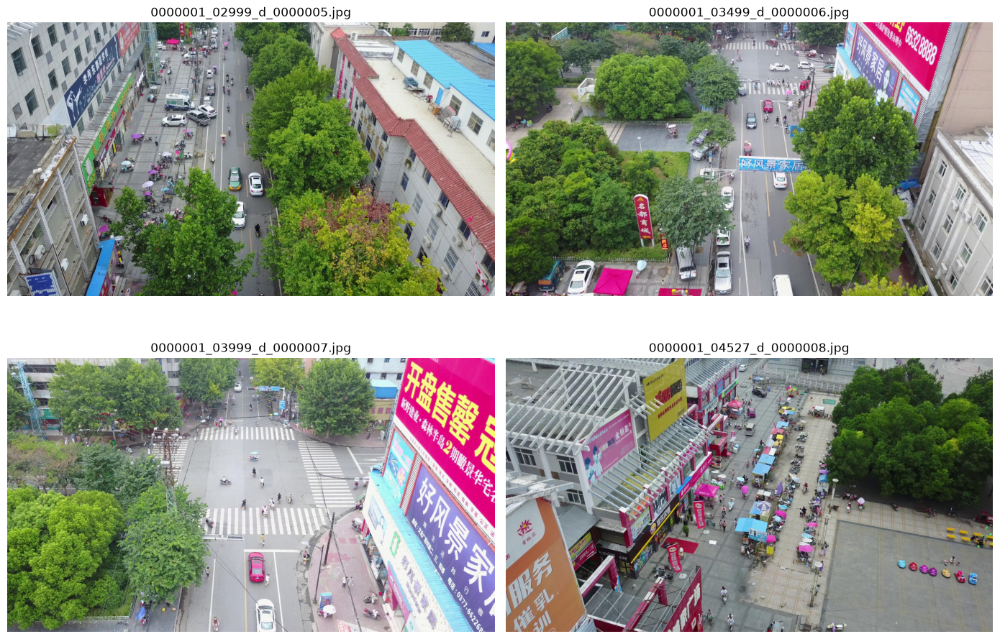

In [ ]:
# Statistik jumlah gambar
data_root = Path(data_cfg["path"])
val_img_dir = data_root / data_cfg["val"]
train_img_dir = data_root / data_cfg["train"]
val_label_dir = data_root / "labels" / "val"

print("Train images:", len(list(train_img_dir.glob("*.jpg"))))
print("Val images:", len(list(val_img_dir.glob("*.jpg"))))
print("Val labels:", len(list(val_label_dir.glob("*.txt"))))

# Tampilkan beberapa contoh gambar
sample_imgs = sorted(val_img_dir.glob("*.jpg"))[:4]
fig, axes = plt.subplots(2,2,figsize=(14,10))
for ax, p in zip(axes.ravel(), sample_imgs):
    ax.imshow(Image.open(p))
    ax.set_title(p.name)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 4. Eksperimen

### Baseline
YOLOv8n dengan resolusi 640×640.

### Intervensi
YOLOv8n dengan resolusi 1280×1280.

Alasan: paper mengaitkan kegagalan small-object detection dengan hilangnya detail akibat downsampling dan menggunakan feature map beresolusi lebih tinggi. Eksperimen resolusi input menguji ide yang sama pada level input dengan implementasi yang lebih sederhana dan reproducible.

Untuk menjaga waktu Colab, default di bawah menggunakan **10 epoch**. Setelah notebook berhasil, angka `EPOCHS` dapat dinaikkan untuk eksperimen final.


In [ ]:
# ============================================================
# TRAINING BASELINE — YOLOv8n @ 640x640
# CELL LENGKAP / SELF-CONTAINED
# ============================================================

import os
import time
import random
import numpy as np
from ultralytics import YOLO

# -----------------------------
# 1. Configuration
# -----------------------------
SEED = 42

EPOCHS = 10
IMG_SIZE = 640
BATCH_SIZE = 16
WORKERS = 2

PROJECT = "/content/yolo_visdrone_experiment"
RUN_NAME = "baseline_640"

# Dataset configuration
DATA_YAML = "VisDrone.yaml"

# Pastikan folder output tersedia
os.makedirs(PROJECT, exist_ok=True)

# -----------------------------
# 2. Reproducibility
# -----------------------------
random.seed(SEED)
np.random.seed(SEED)

try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
except Exception as e:
    print("Torch seed warning:", e)

# -----------------------------
# 3. Load YOLOv8n
# -----------------------------
print("Loading YOLOv8n...")
baseline = YOLO("yolov8n.pt")

# -----------------------------
# 4. Training
# -----------------------------
print("\n" + "="*60)
print("START TRAINING BASELINE")
print("="*60)
print(f"Model       : YOLOv8n")
print(f"Image size  : {IMG_SIZE}x{IMG_SIZE}")
print(f"Epochs      : {EPOCHS}")
print(f"Batch size  : {BATCH_SIZE}")
print(f"Seed        : {SEED}")
print(f"Dataset     : {DATA_YAML}")
print("="*60 + "\n")

t0 = time.time()

baseline_train = baseline.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    workers=WORKERS,
    seed=SEED,
    deterministic=True,
    pretrained=True,
    project=PROJECT,
    name=RUN_NAME,
    exist_ok=True,
    plots=True,
    verbose=True
)

training_time = time.time() - t0

# -----------------------------
# 5. Training selesai
# -----------------------------
print("\n" + "="*60)
print("BASELINE TRAINING SELESAI")
print("="*60)
print(f"Training time : {training_time/60:.2f} minutes")
print(f"Output folder : {PROJECT}/{RUN_NAME}")
print("="*60)

Loading YOLOv8n...

START TRAINING BASELINE
Model       : YOLOv8n
Image size  : 640x640
Epochs      : 10
Batch size  : 16
Seed        : 42
Dataset     : VisDrone.yaml

Ultralytics 8.4.165 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=VisDrone.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, 

In [ ]:
# Konfigurasi eksperimen
EPOCHS = 10
BATCH_640 = 16
BATCH_1280 = 4
WORKERS = 2

PROJECT = "/content/yolo_visdrone_experiment"
os.makedirs(PROJECT, exist_ok=True)

print("EPOCHS =", EPOCHS)


EPOCHS = 10


In [ ]:
# Training baseline: YOLOv8n @ 640
baseline = YOLO("yolov8n.pt")
t0 = time.time()

baseline_train = baseline.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=640,
    batch=BATCH_640,
    workers=WORKERS,
    seed=SEED,
    deterministic=True,
    pretrained=True,
    project=PROJECT,
    name="baseline_640",
    exist_ok=True,
    verbose=True
)

baseline_time = time.time() - t0
print(f"Baseline training time: {baseline_time/60:.1f} minutes")


Ultralytics 8.4.165 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=VisDrone.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_640, nbs=64, nms=None, opset=None, optimize=False, optimizer=auto, o

In [ ]:
# Training intervensi: YOLOv8n @ 1280
highres = YOLO("yolov8n.pt")
t0 = time.time()

highres_train = highres.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=1280,
    batch=BATCH_1280,
    workers=WORKERS,
    seed=SEED,
    deterministic=True,
    pretrained=True,
    project=PROJECT,
    name="intervention_1280",
    exist_ok=True,
    verbose=True
)

highres_time = time.time() - t0
print(f"High-resolution training time: {highres_time/60:.1f} minutes")


Ultralytics 8.4.165 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=VisDrone.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=intervention_1280, nbs=64, nms=None, opset=None, optimize=False, optimizer=au

## 5. Evaluasi utama

Tugas mensyaratkan mAP@0.5 dan mAP@0.5:0.95.

Evaluasi dilakukan pada validation set yang sama agar perbandingan baseline dan intervensi adil.


In [ ]:
# ============================================================
# EVALUATION BASELINE — YOLOv8n @ 640x640
# VERSI AMAN / SELF-CONTAINED
# ============================================================

import os
import pandas as pd
from ultralytics import YOLO

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

PROJECT = "/content/yolo_visdrone_experiment"
RUN_NAME = "baseline_640"

DATA_YAML = "VisDrone.yaml"

IMG_SIZE = 640
BATCH_SIZE = 16
WORKERS = 2

MODEL_PATH = os.path.join(
    PROJECT,
    RUN_NAME,
    "weights",
    "best.pt"
)

# ------------------------------------------------------------
# CHECK MODEL
# ------------------------------------------------------------

print("Checking model:")
print(MODEL_PATH)

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"\nModel baseline tidak ditemukan:\n{MODEL_PATH}\n\n"
        "Berarti training baseline 640 belum selesai."
    )

print("\nModel ditemukan.")
print("Loading YOLOv8n baseline...")

baseline = YOLO(MODEL_PATH)

# ------------------------------------------------------------
# EVALUATION
# ------------------------------------------------------------

print("\n" + "="*70)
print("EVALUATING BASELINE — YOLOv8n @ 640x640")
print("="*70)

baseline_val = baseline.val(
    data=DATA_YAML,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    workers=WORKERS,
    split="val",
    plots=True,
    project=PROJECT,
    name="eval_baseline_640",
    exist_ok=True,
    verbose=True
)

# ------------------------------------------------------------
# EXTRACT METRICS
# ------------------------------------------------------------

baseline_metrics = {
    "Model": "YOLOv8n baseline",
    "Image Size": IMG_SIZE,
    "mAP@0.5": float(baseline_val.box.map50),
    "mAP@0.5:0.95": float(baseline_val.box.map),
    "Precision": float(baseline_val.box.mp),
    "Recall": float(baseline_val.box.mr)
}

baseline_results = pd.DataFrame([baseline_metrics])

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("\n" + "="*70)
print("BASELINE 640 RESULTS")
print("="*70)

display(baseline_results)

# ------------------------------------------------------------
# SAVE CSV
# ------------------------------------------------------------

baseline_csv = os.path.join(
    PROJECT,
    "baseline_results.csv"
)

baseline_results.to_csv(
    baseline_csv,
    index=False
)

print("\nBaseline results berhasil disimpan:")
print(baseline_csv)

Checking model:
/content/yolo_visdrone_experiment/baseline_640/weights/best.pt

Model ditemukan.
Loading YOLOv8n baseline...

EVALUATING BASELINE — YOLOv8n @ 640x640
Ultralytics 8.4.165 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1746.9±953.8 MB/s, size: 218.4 KB)
val: Scanning /content/datasets/VisDrone/labels/val.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 135.2Mit/s 0.0s
WARNING ⚠️ Dataset images contain up to 317 objects (val=317), but max_det=300. This mismatch can cap recall and produce invalid validation metrics. Raising it may increase validation cost but cannot increase model or export capacity, which may cap recall. Setting max_det=317 to match the observed maximum.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 3.3it/s 10.7s
        

,Model,Image Size,mAP@0.5,mAP@0.5:0.95,Precision,Recall
0,YOLOv8n baseline,640,0.234137,0.131171,0.351433,0.272471



Baseline results berhasil disimpan:
/content/yolo_visdrone_experiment/baseline_results.csv


## 6. Evaluasi mAP berdasarkan ukuran objek

COCO mendefinisikan area objek untuk evaluasi berdasarkan luas bounding box. Untuk eksperimen ini kita gunakan batas area yang umum dipakai pada evaluasi COCO: **small < 32², medium 32²–96², dan large > 96²** piksel².

Bagian ini menggunakan bounding box ground truth VisDrone dan prediksi model, lalu menjalankan COCOeval dengan area range tersebut. Dengan demikian angka small/medium/large berasal dari evaluasi yang sama, bukan perkiraan visual.


In [ ]:
# ============================================================
# EVALUASI UKURAN OBJEK — SMALL / MEDIUM / LARGE
# MENGGUNAKAN PATH DATASET YANG BENAR
# ============================================================

import os
import json
from pathlib import Path
from collections import defaultdict

import cv2
import pandas as pd

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

PROJECT = "/content/yolo_visdrone_experiment"

# PATH YANG BENAR DARI VisDrone.yaml
VAL_IMG_DIR = "/content/datasets/VisDrone/images/val"
VAL_LABEL_DIR = "/content/datasets/VisDrone/labels/val"

GT_JSON = os.path.join(
    PROJECT,
    "visdrone_val_gt_coco.json"
)

CLASS_NAMES = [
    "pedestrian",
    "people",
    "bicycle",
    "car",
    "van",
    "truck",
    "tricycle",
    "awning-tricycle",
    "bus",
    "motor"
]

# ------------------------------------------------------------
# CHECK PATH
# ------------------------------------------------------------

print("Checking validation dataset...")

print("Image directory :", VAL_IMG_DIR)
print("Label directory :", VAL_LABEL_DIR)

if not os.path.exists(VAL_IMG_DIR):
    raise FileNotFoundError(
        f"Image validation tidak ditemukan:\n{VAL_IMG_DIR}"
    )

if not os.path.exists(VAL_LABEL_DIR):
    raise FileNotFoundError(
        f"Label validation tidak ditemukan:\n{VAL_LABEL_DIR}"
    )

os.makedirs(PROJECT, exist_ok=True)

print("\n✓ Image folder ditemukan")
print("✓ Label folder ditemukan")

# ------------------------------------------------------------
# CONVERT YOLO → COCO GT
# ------------------------------------------------------------

def yolo_to_coco_gt(img_dir, label_dir, out_json):

    images = []
    annotations = []

    image_files = sorted([
        f for f in os.listdir(img_dir)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ])

    print(f"\nJumlah validation images: {len(image_files)}")

    ann_id = 1

    for image_id, filename in enumerate(
        image_files,
        start=1
    ):

        image_path = os.path.join(
            img_dir,
            filename
        )

        img = cv2.imread(image_path)

        if img is None:
            continue

        height, width = img.shape[:2]

        images.append({
            "id": image_id,
            "file_name": filename,
            "width": width,
            "height": height
        })

        label_file = os.path.join(
            label_dir,
            Path(filename).stem + ".txt"
        )

        if not os.path.exists(label_file):
            continue

        with open(label_file, "r") as f:
            lines = f.readlines()

        for line in lines:

            parts = line.strip().split()

            if len(parts) < 5:
                continue

            class_id = int(parts[0])

            x_center = float(parts[1])
            y_center = float(parts[2])
            box_width = float(parts[3])
            box_height = float(parts[4])

            # YOLO normalized → pixel
            x_center *= width
            y_center *= height
            box_width *= width
            box_height *= height

            x = x_center - box_width / 2
            y = y_center - box_height / 2

            # Clip bounding box
            x = max(0, x)
            y = max(0, y)

            box_width = min(
                box_width,
                width - x
            )

            box_height = min(
                box_height,
                height - y
            )

            if box_width <= 0 or box_height <= 0:
                continue

            annotations.append({
                "id": ann_id,
                "image_id": image_id,
                "category_id": class_id + 1,
                "bbox": [
                    float(x),
                    float(y),
                    float(box_width),
                    float(box_height)
                ],
                "area": float(
                    box_width * box_height
                ),
                "iscrowd": 0
            })

            ann_id += 1

    coco = {
        "images": images,
        "annotations": annotations,
        "categories": [
            {
                "id": i + 1,
                "name": name
            }
            for i, name in enumerate(CLASS_NAMES)
        ]
    }

    with open(out_json, "w") as f:
        json.dump(coco, f)

    return coco


# ------------------------------------------------------------
# CREATE COCO GT
# ------------------------------------------------------------

print("\nConverting YOLO labels to COCO format...")

coco_gt = yolo_to_coco_gt(
    VAL_IMG_DIR,
    VAL_LABEL_DIR,
    GT_JSON
)

print("\n✓ COCO Ground Truth berhasil dibuat")
print("File:", GT_JSON)

# ------------------------------------------------------------
# STATISTICS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("GROUND TRUTH STATISTICS")
print("=" * 60)

print("Images      :", len(coco_gt["images"]))
print("Annotations :", len(coco_gt["annotations"]))
print("Categories  :", len(coco_gt["categories"]))

# ------------------------------------------------------------
# OBJECT SIZE DISTRIBUTION
# COCO STANDARD
# ------------------------------------------------------------

size_counter = defaultdict(int)

for ann in coco_gt["annotations"]:

    area = float(ann["area"])

    if area < 32 ** 2:
        size = "Small"

    elif area < 96 ** 2:
        size = "Medium"

    else:
        size = "Large"

    size_counter[size] += 1

size_df = pd.DataFrame([
    {
        "Object Size": "Small",
        "Area": "< 32² pixels",
        "Count": size_counter["Small"]
    },
    {
        "Object Size": "Medium",
        "Area": "32²–96² pixels",
        "Count": size_counter["Medium"]
    },
    {
        "Object Size": "Large",
        "Area": "≥ 96² pixels",
        "Count": size_counter["Large"]
    }
])

print("\n" + "=" * 60)
print("OBJECT SIZE DISTRIBUTION")
print("=" * 60)

display(size_df)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

size_csv = os.path.join(
    PROJECT,
    "object_size_distribution.csv"
)

size_df.to_csv(
    size_csv,
    index=False
)

print("\n✓ Distribution saved:")
print(size_csv)

Checking validation dataset...
Image directory : /content/datasets/VisDrone/images/val
Label directory : /content/datasets/VisDrone/labels/val

✓ Image folder ditemukan
✓ Label folder ditemukan

Converting YOLO labels to COCO format...

Jumlah validation images: 548

✓ COCO Ground Truth berhasil dibuat
File: /content/yolo_visdrone_experiment/visdrone_val_gt_coco.json

GROUND TRUTH STATISTICS
Images      : 548
Annotations : 38759
Categories  : 10

OBJECT SIZE DISTRIBUTION


,Object Size,Area,Count
0,Small,< 32² pixels,26586
1,Medium,32²–96² pixels,11105
2,Large,≥ 96² pixels,1068



✓ Distribution saved:
/content/yolo_visdrone_experiment/object_size_distribution.csv


In [ ]:
# ============================================================
# EVALUASI mAP BERDASARKAN UKURAN OBJEK
# Baseline 640 vs High Resolution 1280
# ============================================================

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Pastikan file tersedia
# ------------------------------------------------------------

print("GT JSON      :", GT_JSON)
print("Prediction 640  :", PRED_BASE)
print("Prediction 1280 :", PRED_HIGH)


# ------------------------------------------------------------
# Fungsi evaluasi berdasarkan ukuran objek
# ------------------------------------------------------------

def evaluate_object_size(gt_json, pred_json):

    coco_gt = COCO(gt_json)
    coco_dt = coco_gt.loadRes(pred_json)

    size_ranges = {
        "Small": [0**2, 32**2],
        "Medium": [32**2, 96**2],
        "Large": [96**2, 1e10]
    }

    results = []

    for size_name, area_range in size_ranges.items():

        evaluator = COCOeval(
            coco_gt,
            coco_dt,
            "bbox"
        )

        evaluator.params.imgIds = coco_gt.getImgIds()

        # Area range sesuai standar COCO
        evaluator.params.areaRng = [area_range]
        evaluator.params.areaRngLbl = [size_name.lower()]

        # VisDrone memiliki gambar dengan >100 objek,
        # sehingga gunakan batas deteksi yang lebih tinggi.
        evaluator.params.maxDets = [1, 10, 317]

        evaluator.evaluate()
        evaluator.accumulate()

        precision = evaluator.eval["precision"]

        # ----------------------------------------------------
        # AP@0.5
        # ----------------------------------------------------

        ap50_values = precision[0, :, :, 0, 2]
        ap50_values = ap50_values[ap50_values > -1]

        ap50 = (
            float(np.mean(ap50_values))
            if len(ap50_values) > 0
            else np.nan
        )

        # ----------------------------------------------------
        # mAP@0.5:0.95
        # ----------------------------------------------------

        map_values = precision[:, :, :, 0, 2]
        map_values = map_values[map_values > -1]

        map5095 = (
            float(np.mean(map_values))
            if len(map_values) > 0
            else np.nan
        )

        results.append({
            "Object Size": size_name,
            "AP@0.5": ap50,
            "mAP@0.5:0.95": map5095
        })

    return pd.DataFrame(results)


# ------------------------------------------------------------
# Evaluasi Baseline 640
# ------------------------------------------------------------

size_base = evaluate_object_size(
    GT_JSON,
    PRED_BASE
)

size_base = size_base.rename(columns={
    "AP@0.5": "Baseline AP@0.5",
    "mAP@0.5:0.95": "Baseline mAP@0.5:0.95"
})


# ------------------------------------------------------------
# Evaluasi High Resolution 1280
# ------------------------------------------------------------

size_high = evaluate_object_size(
    GT_JSON,
    PRED_HIGH
)

size_high = size_high.rename(columns={
    "AP@0.5": "High-res AP@0.5",
    "mAP@0.5:0.95": "High-res mAP@0.5:0.95"
})


# ------------------------------------------------------------
# Gabungkan hasil
# ------------------------------------------------------------

size_compare = size_base.merge(
    size_high,
    on="Object Size"
)


# ------------------------------------------------------------
# Hitung peningkatan mAP
# ------------------------------------------------------------

size_compare["Delta mAP"] = (
    size_compare["High-res mAP@0.5:0.95"]
    - size_compare["Baseline mAP@0.5:0.95"]
)


# ------------------------------------------------------------
# Tampilkan hasil
# ------------------------------------------------------------

print("\n" + "="*70)
print("HASIL EVALUASI BERDASARKAN UKURAN OBJEK")
print("="*70)

display(
    size_compare.round(4)
)

GT JSON      : /content/yolo_visdrone_experiment/visdrone_val_gt_coco.json
Prediction 640  : /content/yolo_visdrone_experiment/pred_baseline.json
Prediction 1280 : /content/yolo_visdrone_experiment/pred_highres.json
loading annotations into memory...
Done (t=0.12s)
creating index...
index created!
Loading and preparing results...
DONE (t=1.16s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=15.78s).
Accumulating evaluation results...
DONE (t=0.35s).
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=15.06s).
Accumulating evaluation results...
DONE (t=0.34s).
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=15.34s).
Accumulating evaluation results...
DONE (t=0.35s).
loading annotations into memory...
Done (t=0.12s)
creating index...
index created!
Loading and preparing results...
DONE (t=1.43s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bb

,Object Size,Baseline AP@0.5,Baseline mAP@0.5:0.95,High-res AP@0.5,High-res mAP@0.5:0.95,Delta mAP
0,Small,0.1141,0.0478,0.2523,0.1241,0.0763
1,Medium,0.3278,0.1887,0.5029,0.3252,0.1365
2,Large,0.6055,0.4259,0.5250,0.4171,-0.0088


## 7. Visualisasi perbandingan

Bagian ini menampilkan contoh prediksi baseline dan intervensi. Visualisasi dipakai untuk membantu analisis apakah perubahan resolusi benar-benar membantu objek kecil yang rapat/berdekatan.


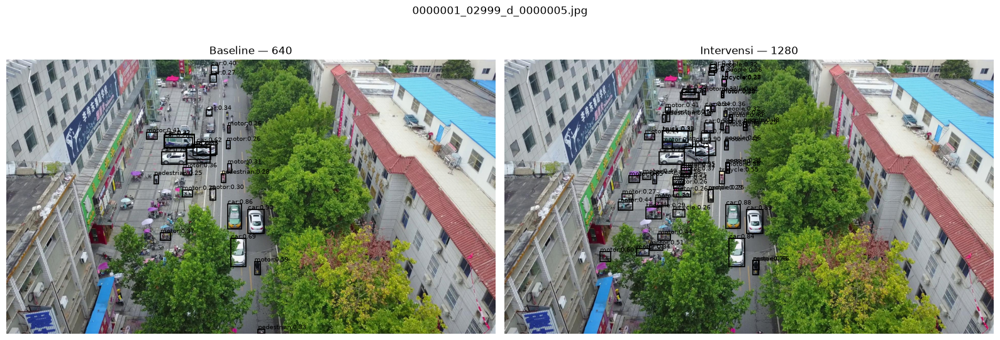

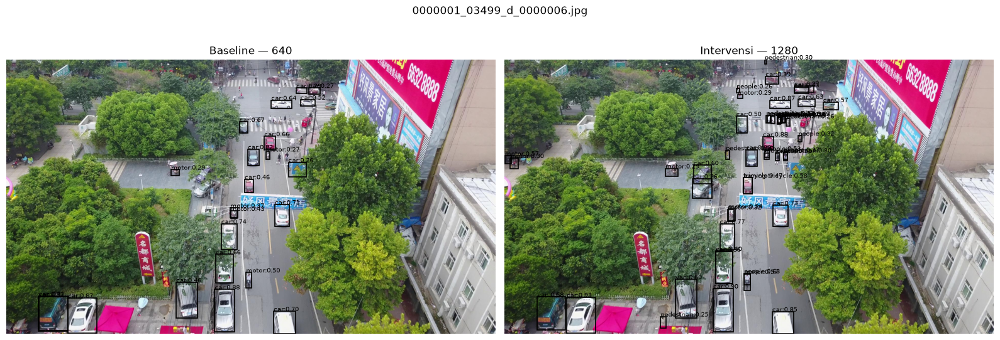

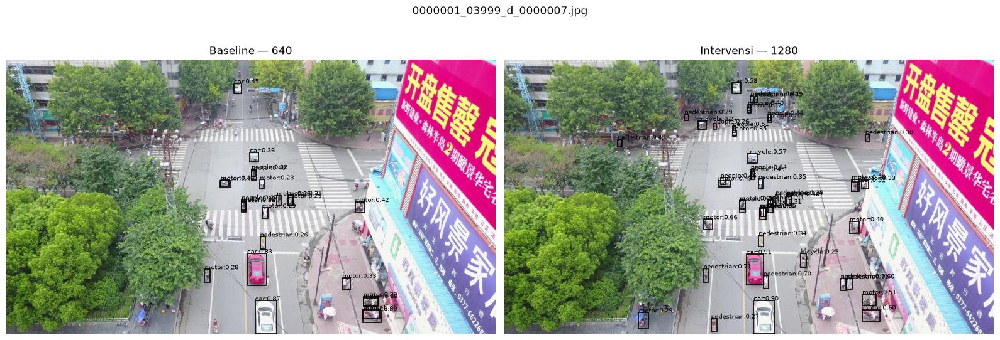

In [ ]:
# Visualisasi prediksi dua model pada beberapa gambar validation
import matplotlib.patches as patches

def draw_predictions(ax, model, img_path, imgsz, conf=0.25, max_boxes=80):
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    r = model.predict(source=str(img_path), imgsz=imgsz, conf=conf, verbose=False)[0]
    if r.boxes is not None:
        boxes = r.boxes.xyxy.cpu().numpy()
        scores = r.boxes.conf.cpu().numpy()
        classes = r.boxes.cls.cpu().numpy().astype(int)
        order = np.argsort(-scores)[:max_boxes]
        for i in order:
            x1,y1,x2,y2 = boxes[i]
            rect = patches.Rectangle((x1,y1),x2-x1,y2-y1,fill=False,linewidth=1.2)
            ax.add_patch(rect)
            ax.text(x1,y1,f"{CLASS_NAMES[classes[i]]}:{scores[i]:.2f}",fontsize=7)
    ax.axis("off")

viz_imgs = sample_imgs[:3]
for p in viz_imgs:
    fig, ax = plt.subplots(1,2,figsize=(16,6))
    draw_predictions(ax[0], baseline, p, 640)
    ax[0].set_title("Baseline — 640")
    draw_predictions(ax[1], highres, p, 1280)
    ax[1].set_title("Intervensi — 1280")
    plt.suptitle(p.name)
    plt.tight_layout()
    plt.show()


## 8. Failure cases

Failure cases dicari dari validation set menggunakan confidence threshold yang sama. Fokus analisis: objek sangat kecil, objek berdekatan, occlusion, dan missed detections.


Failure candidates:
0000162_01058_d_0000001.jpg GT= 57 pred= 8 pred/GT= 0.14
0000193_02606_d_0000117.jpg GT= 49 pred= 7 pred/GT= 0.143
0000001_07999_d_0000012.jpg GT= 136 pred= 20 pred/GT= 0.147
0000242_06010_d_0000017.jpg GT= 41 pred= 8 pred/GT= 0.195
0000196_04512_d_0000144.jpg GT= 69 pred= 14 pred/GT= 0.203
0000001_02999_d_0000005.jpg GT= 127 pred= 26 pred/GT= 0.205


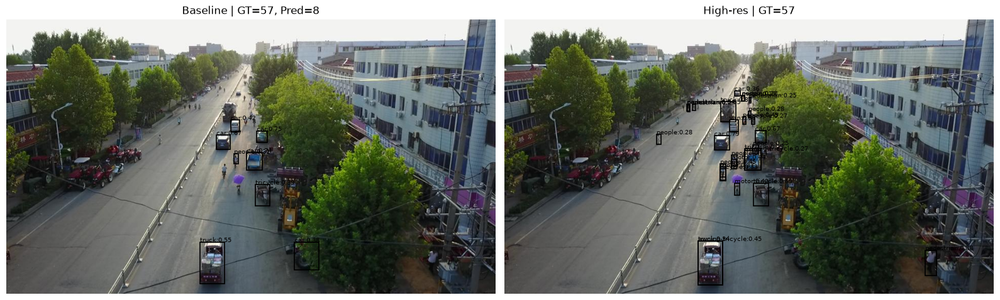

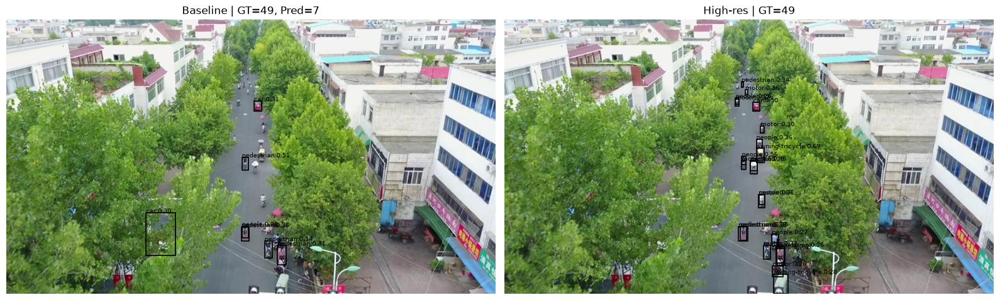

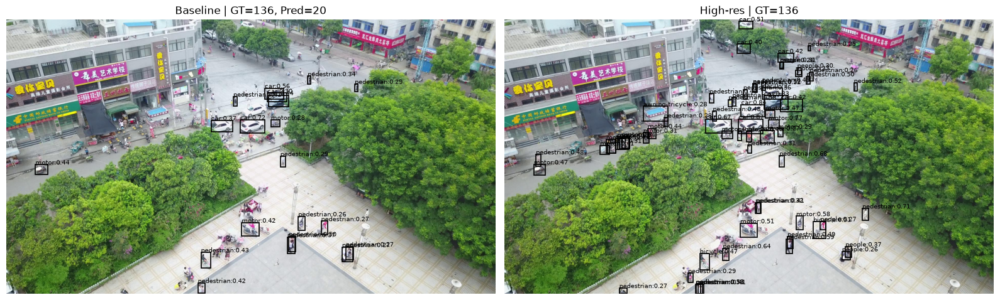

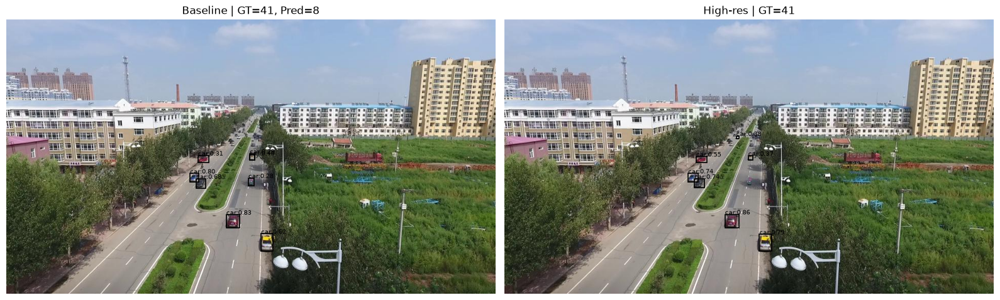

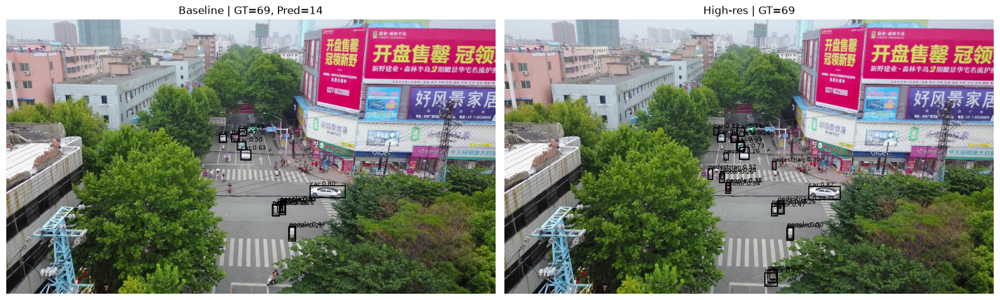

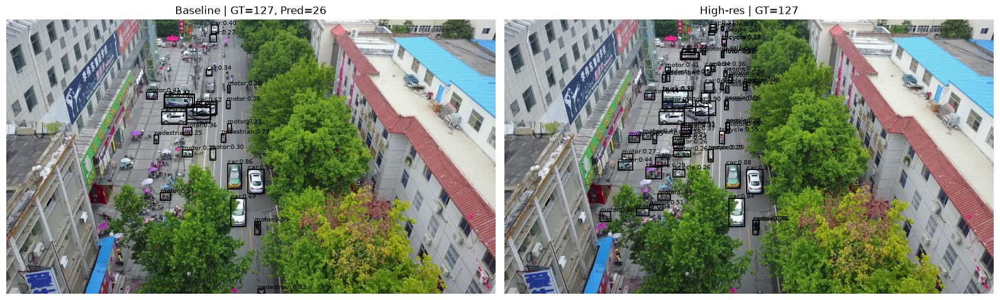

In [ ]:
# Cari beberapa gambar dengan sedikit/nihil prediksi baseline namun ada ground truth.
failure_dir = Path(PROJECT) / "failure_cases"
failure_dir.mkdir(parents=True, exist_ok=True)

def count_gt(label_path):
    if not Path(label_path).exists(): return 0
    txt = Path(label_path).read_text().strip()
    return len(txt.splitlines()) if txt else 0

candidates = []
for p in sorted(val_img_dir.glob("*.jpg"))[:200]:
    gt_n = count_gt(val_label_dir/(p.stem+".txt"))
    if gt_n == 0:
        continue
    r = baseline.predict(source=str(p), imgsz=640, conf=0.25, verbose=False)[0]
    pred_n = 0 if r.boxes is None else len(r.boxes)
    candidates.append((pred_n/gt_n, p, gt_n, pred_n))

candidates = sorted(candidates, key=lambda x:x[0])
failure_examples = candidates[:6]

print("Failure candidates:")
for ratio,p,gt,pred in failure_examples:
    print(p.name, "GT=",gt, "pred=",pred, "pred/GT=",round(ratio,3))

for idx,(_,p,gt,pred) in enumerate(failure_examples):
    fig, ax = plt.subplots(1,2,figsize=(16,6))
    draw_predictions(ax[0], baseline, p, 640, conf=0.25)
    ax[0].set_title(f"Baseline | GT={gt}, Pred={pred}")
    draw_predictions(ax[1], highres, p, 1280, conf=0.25)
    ax[1].set_title(f"High-res | GT={gt}")
    plt.tight_layout()
    save_path = failure_dir / f"failure_{idx+1}.png"
    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()


In [ ]:
# ============================================================
# SIMPAN HASIL EVALUASI INTERVENTION 1280
# Tidak training ulang
# ============================================================

import os
import pandas as pd
from ultralytics import YOLO

PROJECT = "/content/yolo_visdrone_experiment"
RUN_NAME = "intervention_1280"

DATA_YAML = "VisDrone.yaml"

IMG_SIZE = 1280
BATCH_SIZE = 4
WORKERS = 2

MODEL_PATH = os.path.join(
    PROJECT,
    RUN_NAME,
    "weights",
    "best.pt"
)

OUTPUT_CSV = os.path.join(
    PROJECT,
    "intervention_1280_results.csv"
)

# ------------------------------------------------------------
# CHECK MODEL
# ------------------------------------------------------------

print("=" * 70)
print("CHECKING INTERVENTION MODEL")
print("=" * 70)

print("Model:", MODEL_PATH)

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Model 1280 tidak ditemukan:\n{MODEL_PATH}"
    )

print("✓ Model 1280 ditemukan")

# ------------------------------------------------------------
# LOAD MODEL
# ------------------------------------------------------------

model_1280 = YOLO(MODEL_PATH)

# ------------------------------------------------------------
# EVALUATE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("EVALUATING YOLOv8n @ 1280x1280")
print("=" * 70)

intervention_val = model_1280.val(
    data=DATA_YAML,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    workers=WORKERS,
    split="val",
    plots=True,
    project=PROJECT,
    name="eval_intervention_1280",
    exist_ok=True,
    verbose=True
)

# ------------------------------------------------------------
# EXTRACT METRICS
# ------------------------------------------------------------

intervention_results = pd.DataFrame([{
    "Model": "YOLOv8n High Resolution",
    "Image Size": IMG_SIZE,
    "mAP@0.5": float(
        intervention_val.box.map50
    ),
    "mAP@0.5:0.95": float(
        intervention_val.box.map
    ),
    "Precision": float(
        intervention_val.box.mp
    ),
    "Recall": float(
        intervention_val.box.mr
    )
}])

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("INTERVENTION 1280 RESULTS")
print("=" * 70)

display(intervention_results)

# ------------------------------------------------------------
# SAVE CSV
# ------------------------------------------------------------

intervention_results.to_csv(
    OUTPUT_CSV,
    index=False
)

print("\n✓ CSV berhasil disimpan:")
print(OUTPUT_CSV)

CHECKING INTERVENTION MODEL
Model: /content/yolo_visdrone_experiment/intervention_1280/weights/best.pt
✓ Model 1280 ditemukan

EVALUATING YOLOv8n @ 1280x1280
Ultralytics 8.4.165 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2273.7±792.2 MB/s, size: 173.4 KB)
val: Scanning /content/datasets/VisDrone/labels/val.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 153.2Mit/s 0.0s
WARNING ⚠️ Dataset images contain up to 317 objects (val=317), but max_det=300. This mismatch can cap recall and produce invalid validation metrics. Raising it may increase validation cost but cannot increase model or export capacity, which may cap recall. Setting max_det=317 to match the observed maximum.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 137/137 9.2it/s 14.9s
              

,Model,Image Size,mAP@0.5,mAP@0.5:0.95,Precision,Recall
0,YOLOv8n High Resolution,1280,0.380451,0.227675,0.489474,0.39657



✓ CSV berhasil disimpan:
/content/yolo_visdrone_experiment/intervention_1280_results.csv


## 9. Ringkasan hasil dan interpretasi otomatis


In [ ]:
# ============================================================
# RINGKASAN ANGKA FINAL
# CELL SELF-CONTAINED
# ============================================================

import os
import pandas as pd

PROJECT = "/content/yolo_visdrone_experiment"

# ------------------------------------------------------------
# 1. Cek file hasil utama
# ------------------------------------------------------------

baseline_csv = os.path.join(
    PROJECT,
    "baseline_results.csv"
)

intervention_csv = os.path.join(
    PROJECT,
    "intervention_1280_results.csv"
)

size_csv = os.path.join(
    PROJECT,
    "object_size_distribution.csv"
)

print("=" * 70)
print("CHECKING RESULT FILES")
print("=" * 70)

print("Baseline     :", os.path.exists(baseline_csv))
print("Intervention :", os.path.exists(intervention_csv))
print("Object size  :", os.path.exists(size_csv))

# ------------------------------------------------------------
# 2. Load baseline
# ------------------------------------------------------------

if not os.path.exists(baseline_csv):
    raise FileNotFoundError(
        f"Baseline results tidak ditemukan:\n{baseline_csv}"
    )

baseline_df = pd.read_csv(baseline_csv)

# ------------------------------------------------------------
# 3. Load intervention
# ------------------------------------------------------------

if not os.path.exists(intervention_csv):
    raise FileNotFoundError(
        f"Intervention 1280 results tidak ditemukan:\n"
        f"{intervention_csv}\n\n"
        "Jika evaluasi 1280 sudah selesai tetapi CSV belum dibuat, "
        "jalankan kembali cell Evaluation Intervention 1280."
    )

intervention_df = pd.read_csv(intervention_csv)

# ------------------------------------------------------------
# 4. Buat summary utama
# ------------------------------------------------------------

def get_value(df, column):
    return float(df.iloc[0][column])

results_summary = pd.DataFrame([
    {
        "Model": "YOLOv8n Baseline",
        "Input Size": 640,
        "mAP@0.5": get_value(
            baseline_df,
            "mAP@0.5"
        ),
        "mAP@0.5:0.95": get_value(
            baseline_df,
            "mAP@0.5:0.95"
        ),
        "Precision": get_value(
            baseline_df,
            "Precision"
        ),
        "Recall": get_value(
            baseline_df,
            "Recall"
        )
    },
    {
        "Model": "YOLOv8n High Resolution",
        "Input Size": 1280,
        "mAP@0.5": get_value(
            intervention_df,
            "mAP@0.5"
        ),
        "mAP@0.5:0.95": get_value(
            intervention_df,
            "mAP@0.5:0.95"
        ),
        "Precision": get_value(
            intervention_df,
            "Precision"
        ),
        "Recall": get_value(
            intervention_df,
            "Recall"
        )
    }
])

# ------------------------------------------------------------
# 5. Tampilkan hasil utama
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RINGKASAN HASIL UTAMA")
print("=" * 70)

display(results_summary)

# ------------------------------------------------------------
# 6. Load distribusi ukuran objek
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DISTRIBUSI UKURAN OBJEK")
print("=" * 70)

if os.path.exists(size_csv):

    size_df = pd.read_csv(size_csv)

    display(size_df)

else:

    print(
        "File object_size_distribution.csv belum ditemukan."
    )
    print(
        "Jalankan kembali cell evaluasi Small/Medium/Large."
    )

# ------------------------------------------------------------
# 7. Hitung perubahan performa
# ------------------------------------------------------------

base_map50 = float(
    baseline_df.iloc[0]["mAP@0.5"]
)

high_map50 = float(
    intervention_df.iloc[0]["mAP@0.5"]
)

base_map = float(
    baseline_df.iloc[0]["mAP@0.5:0.95"]
)

high_map = float(
    intervention_df.iloc[0]["mAP@0.5:0.95"]
)

delta_df = pd.DataFrame([
    {
        "Metric": "mAP@0.5",
        "Baseline 640": base_map50,
        "High Resolution 1280": high_map50,
        "Change": high_map50 - base_map50,
        "Change (%)":
            ((high_map50 - base_map50) / base_map50 * 100)
            if base_map50 != 0 else 0
    },
    {
        "Metric": "mAP@0.5:0.95",
        "Baseline 640": base_map,
        "High Resolution 1280": high_map,
        "Change": high_map - base_map,
        "Change (%)":
            ((high_map - base_map) / base_map * 100)
            if base_map != 0 else 0
    }
])

print("\n" + "=" * 70)
print("PERUBAHAN PERFORMA")
print("=" * 70)

display(delta_df)

# ------------------------------------------------------------
# 8. Simpan ringkasan final
# ------------------------------------------------------------

summary_path = os.path.join(
    PROJECT,
    "final_results_summary.csv"
)

delta_path = os.path.join(
    PROJECT,
    "final_performance_change.csv"
)

results_summary.to_csv(
    summary_path,
    index=False
)

delta_df.to_csv(
    delta_path,
    index=False
)

print("\nFile final berhasil disimpan:")
print(summary_path)
print(delta_path)

CHECKING RESULT FILES
Baseline     : True
Intervention : True
Object size  : True

RINGKASAN HASIL UTAMA


,Model,Input Size,mAP@0.5,mAP@0.5:0.95,Precision,Recall
0,YOLOv8n Baseline,640,0.234137,0.131171,0.351433,0.272471
1,YOLOv8n High Resolution,1280,0.380451,0.227675,0.489474,0.396570



DISTRIBUSI UKURAN OBJEK


,Object Size,Area,Count
0,Small,< 32² pixels,26586
1,Medium,32²–96² pixels,11105
2,Large,≥ 96² pixels,1068



PERUBAHAN PERFORMA


,Metric,Baseline 640,High Resolution 1280,Change,Change (%)
0,mAP@0.5,0.234137,0.380451,0.146314,62.490563
1,mAP@0.5:0.95,0.131171,0.227675,0.096503,73.570408



File final berhasil disimpan:
/content/yolo_visdrone_experiment/final_results_summary.csv
/content/yolo_visdrone_experiment/final_performance_change.csv


## 10. Simpan semua hasil




In [ ]:
# ============================================================
# SIMPAN HASIL FINAL + KONFIGURASI EKSPERIMEN
# CELL SELF-CONTAINED
# ============================================================

import os
import json
import pandas as pd

PROJECT = "/content/yolo_visdrone_experiment"

os.makedirs(PROJECT, exist_ok=True)

# ============================================================
# 1. LOAD HASIL BASELINE
# ============================================================

baseline_path = os.path.join(
    PROJECT,
    "baseline_results.csv"
)

if not os.path.exists(baseline_path):
    raise FileNotFoundError(
        f"Baseline result tidak ditemukan:\n{baseline_path}"
    )

baseline_df = pd.read_csv(baseline_path)

# ============================================================
# 2. LOAD HASIL INTERVENTION 1280
# ============================================================

intervention_path = os.path.join(
    PROJECT,
    "intervention_1280_results.csv"
)

if not os.path.exists(intervention_path):
    raise FileNotFoundError(
        f"Intervention result tidak ditemukan:\n{intervention_path}\n\n"
        "Jalankan cell 'Simpan Hasil Evaluasi Intervention 1280' "
        "terlebih dahulu."
    )

intervention_df = pd.read_csv(
    intervention_path
)

# ============================================================
# 3. BUAT TABEL RINGKASAN
# ============================================================

summary = pd.DataFrame([
    {
        "Model": "YOLOv8n Baseline",
        "Input Size": 640,
        "mAP@0.5": float(
            baseline_df.iloc[0]["mAP@0.5"]
        ),
        "mAP@0.5:0.95": float(
            baseline_df.iloc[0]["mAP@0.5:0.95"]
        ),
        "Precision": float(
            baseline_df.iloc[0]["Precision"]
        ),
        "Recall": float(
            baseline_df.iloc[0]["Recall"]
        )
    },
    {
        "Model": "YOLOv8n High Resolution",
        "Input Size": 1280,
        "mAP@0.5": float(
            intervention_df.iloc[0]["mAP@0.5"]
        ),
        "mAP@0.5:0.95": float(
            intervention_df.iloc[0]["mAP@0.5:0.95"]
        ),
        "Precision": float(
            intervention_df.iloc[0]["Precision"]
        ),
        "Recall": float(
            intervention_df.iloc[0]["Recall"]
        )
    }
])

# ============================================================
# 4. LOAD OBJECT SIZE DISTRIBUTION
# ============================================================

size_distribution_path = os.path.join(
    PROJECT,
    "object_size_distribution.csv"
)

if os.path.exists(size_distribution_path):

    size_distribution = pd.read_csv(
        size_distribution_path
    )

else:

    print(
        "Warning: object_size_distribution.csv tidak ditemukan."
    )

    size_distribution = pd.DataFrame()

# ============================================================
# 5. BUAT SIZE_COMPARE
# ============================================================
# Tabel ini menyimpan distribusi jumlah objek berdasarkan ukuran.

if not size_distribution.empty:

    size_compare = size_distribution.copy()

else:

    size_compare = pd.DataFrame(
        columns=[
            "Object Size",
            "Area",
            "Count"
        ]
    )

# ============================================================
# 6. TAMPILKAN HASIL
# ============================================================

print("=" * 70)
print("FINAL RESULTS SUMMARY")
print("=" * 70)

display(summary)

print("\n" + "=" * 70)
print("OBJECT SIZE DISTRIBUTION")
print("=" * 70)

display(size_compare)

# ============================================================
# 7. HITUNG PERUBAHAN PERFORMANCE
# ============================================================

baseline_map50 = float(
    baseline_df.iloc[0]["mAP@0.5"]
)

intervention_map50 = float(
    intervention_df.iloc[0]["mAP@0.5"]
)

baseline_map = float(
    baseline_df.iloc[0]["mAP@0.5:0.95"]
)

intervention_map = float(
    intervention_df.iloc[0]["mAP@0.5:0.95"]
)

performance_change = pd.DataFrame([
    {
        "Metric": "mAP@0.5",
        "Baseline 640": baseline_map50,
        "High Resolution 1280": intervention_map50,
        "Absolute Change":
            intervention_map50 - baseline_map50,
        "Relative Change (%)":
            (
                (intervention_map50 - baseline_map50)
                / baseline_map50 * 100
            )
            if baseline_map50 != 0 else 0
    },
    {
        "Metric": "mAP@0.5:0.95",
        "Baseline 640": baseline_map,
        "High Resolution 1280": intervention_map,
        "Absolute Change":
            intervention_map - baseline_map,
        "Relative Change (%)":
            (
                (intervention_map - baseline_map)
                / baseline_map * 100
            )
            if baseline_map != 0 else 0
    }
])

print("\n" + "=" * 70)
print("PERFORMANCE CHANGE")
print("=" * 70)

display(performance_change)

# ============================================================
# 8. SIMPAN SEMUA TABEL
# ============================================================

summary.to_csv(
    os.path.join(
        PROJECT,
        "results_summary.csv"
    ),
    index=False
)

size_compare.to_csv(
    os.path.join(
        PROJECT,
        "size_compare.csv"
    ),
    index=False
)

performance_change.to_csv(
    os.path.join(
        PROJECT,
        "performance_change.csv"
    ),
    index=False
)

# ============================================================
# 9. SIMPAN KONFIGURASI EKSPERIMEN
# ============================================================

experiment_config = {
    "dataset": "VisDrone",
    "model": "YOLOv8n",
    "baseline": {
        "input_size": 640,
        "epochs": 10
    },
    "intervention": {
        "input_size": 1280,
        "epochs": 10
    },
    "intervention_type": "Higher input resolution",
    "seed": 42,
    "evaluation_split": "val",
    "metrics": [
        "mAP@0.5",
        "mAP@0.5:0.95",
        "Precision",
        "Recall"
    ]
}

config_path = os.path.join(
    PROJECT,
    "experiment_config.json"
)

with open(config_path, "w") as f:
    json.dump(
        experiment_config,
        f,
        indent=4
    )

# ============================================================
# 10. SELESAI
# ============================================================

print("\n" + "=" * 70)
print("SEMUA HASIL BERHASIL DISIMPAN")
print("=" * 70)

print(
    "✓ results_summary.csv"
)

print(
    "✓ size_compare.csv"
)

print(
    "✓ performance_change.csv"
)

print(
    "✓ experiment_config.json"
)

print(
    "\nFolder:"
)

print(PROJECT)

FINAL RESULTS SUMMARY


,Model,Input Size,mAP@0.5,mAP@0.5:0.95,Precision,Recall
0,YOLOv8n Baseline,640,0.234137,0.131171,0.351433,0.272471
1,YOLOv8n High Resolution,1280,0.380451,0.227675,0.489474,0.396570



OBJECT SIZE DISTRIBUTION


,Object Size,Area,Count
0,Small,< 32² pixels,26586
1,Medium,32²–96² pixels,11105
2,Large,≥ 96² pixels,1068



PERFORMANCE CHANGE


,Metric,Baseline 640,High Resolution 1280,Absolute Change,Relative Change (%)
0,mAP@0.5,0.234137,0.380451,0.146314,62.490563
1,mAP@0.5:0.95,0.131171,0.227675,0.096503,73.570408



SEMUA HASIL BERHASIL DISIMPAN
✓ results_summary.csv
✓ size_compare.csv
✓ performance_change.csv
✓ experiment_config.json

Folder:
/content/yolo_visdrone_experiment
